In [11]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency: Literal["INR", "EUR"]
    total: float

In [12]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 85
    return state

def convert_to_eur(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.9
    return state

def choose_conversion(state: PortfolioState) -> str:
    return state['target_currency']

In [18]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_eur_node", convert_to_eur)


builder.add_edge(START,  "calc_total_node")
builder.add_conditional_edges(
    "calc_total_node",
    choose_conversion,
    {
        "INR": "convert_to_inr_node",
        "EUR": "convert_to_eur_node"
    }
)
builder.add_edge(["convert_to_inr_node", "convert_to_eur_node"], END )

graph = builder.compile()

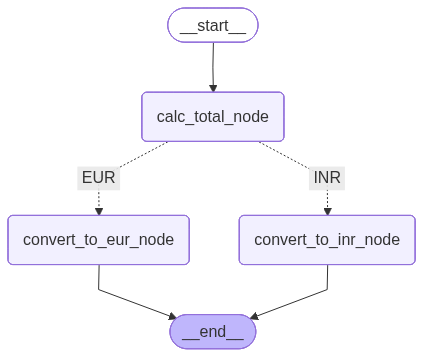

In [19]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
graph.invoke({"amount_usd": 100, "target_currency": "EUR"})

{'amount_usd': 100,
 'total_usd': 108.0,
 'target_currency': 'EUR',
 'total': 97.2}